Raw dataset shape: (100000, 33)
Encoded feature matrix shape: (100000, 32)
Class counts:
 diagnosed_diabetes
1    59998
0    40002
Name: count, dtype: int64

Safe k_list: [6, 8, 10, 20, 30, 'all']

Training RandomizedSearchCV for diagnosed_diabetes...
Fitting 5 folds for each of 60 candidates, totalling 300 fits


/apps/python/3.10/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



BEST CV F1: 0.7434
BEST PARAMS:
 {'feature_selection__k': 'all', 'classifier__n_estimators': 300, 'classifier__min_samples_split': 5, 'classifier__min_samples_leaf': 2, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 8, 'classifier__class_weight': None, 'classifier__bootstrap': False}

Best k: all | selected: 32
Selected features (first 60): ['age', 'alcohol_consumption_per_week', 'physical_activity_minutes_per_week', 'diet_score', 'sleep_hours_per_day', 'screen_time_hours_per_day', 'family_history_diabetes', 'hypertension_history', 'cardiovascular_history', 'bmi', 'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate', 'gender_Male', 'gender_Other', 'ethnicity_Black', 'ethnicity_Hispanic', 'ethnicity_Other', 'ethnicity_White', 'education_level_Highschool', 'education_level_No formal', 'education_level_Postgraduate', 'income_level_Low', 'income_level_Lower-Middle', 'income_level_Middle', 'income_level_Upper-Middle', 'employment_status_Retired', 'employment_stat

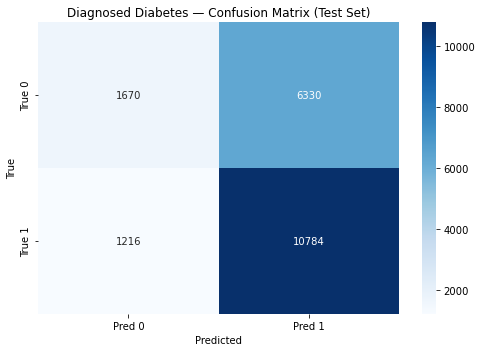


TN FP
FN TP
 [[ 1670  6330]
 [ 1216 10784]]

Classification report:
               precision    recall  f1-score   support

           0       0.58      0.21      0.31      8000
           1       0.63      0.90      0.74     12000

    accuracy                           0.62     20000
   macro avg       0.60      0.55      0.52     20000
weighted avg       0.61      0.62      0.57     20000


Top 10 trials:
 rank_test_score  mean_test_score  std_test_score                                                                                                                                                                                                                                                                     params
               1         0.743378        0.001451  {'feature_selection__k': 'all', 'classifier__n_estimators': 300, 'classifier__min_samples_split': 5, 'classifier__min_samples_leaf': 2, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 8, 'classifier__class_

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
)

RANDOM_STATE = 42
N_FOLDS = 5

# ----------------------------
# 1) Load + prepare data
# ----------------------------
df = pd.read_csv("diagnosed_diabetes for classification.csv")
y = df["diagnosed_diabetes"].astype(int)
X_raw = df.drop(columns=["diagnosed_diabetes"])

# one-hot + numeric
X = pd.get_dummies(X_raw, drop_first=False)
X = X.apply(pd.to_numeric, errors="coerce").fillna(0)

print("Raw dataset shape:", df.shape)
print("Encoded feature matrix shape:", X.shape)
print("Class counts:\n", y.value_counts())

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

# ----------------------------
# 2) Safe k choices (no k > n_features)
# ----------------------------
n_features = X_train.shape[1]
candidate_k = [6, 8, 10, 20, 30, 50, 100]
k_list = sorted({k for k in candidate_k if k <= n_features})
k_list += ["all"]  # always allow "all"

print("\nSafe k_list:", k_list)

# ----------------------------
# 3) CV + Pipeline
# ----------------------------
cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

pipeline = Pipeline([
    ("feature_selection", SelectKBest(score_func=f_classif)),
    # n_jobs=1 avoids nested parallel slowdown; RandomizedSearch uses n_jobs=-1
    ("classifier", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1))
])

# ----------------------------
# 4) RandomizedSearch space (fast + strong)
# ----------------------------
param_distributions = {
    "feature_selection__k": k_list,

    "classifier__n_estimators": [200, 300, 500, 800],
    "classifier__max_depth": [None, 8, 12, 16, 20],
    "classifier__min_samples_leaf": [1, 2, 5, 10, 20],
    "classifier__min_samples_split": [2, 5, 10, 20],
    "classifier__max_features": ["sqrt", "log2", 0.3, 0.5, 0.8],
    "classifier__bootstrap": [True, False],
    "classifier__class_weight": [None, "balanced_subsample"],  # imbalance handling
}

search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_distributions,
    n_iter=60,                 # increase to 80-120 for better search
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1,
    return_train_score=False
)

print("\nTraining RandomizedSearchCV for diagnosed_diabetes...")
search.fit(X_train, y_train)

best_model = search.best_estimator_

print("\n" + "="*70)
print("BEST CV F1:", f"{search.best_score_:.4f}")
print("BEST PARAMS:\n", search.best_params_)
print("="*70)

# ----------------------------
# 5) Selected features
# ----------------------------
selector = best_model.named_steps["feature_selection"]
k_best = selector.k

if k_best == "all":
    selected_names = list(X_train.columns)
else:
    idx = selector.get_support(indices=True)
    selected_names = X_train.columns[idx].tolist()

print("\nBest k:", k_best, "| selected:", len(selected_names))
print("Selected features (first 60):", selected_names[:60])

# ----------------------------
# 6) Test evaluation + confusion matrix heatmap
# ----------------------------
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
roc = roc_auc_score(y_test, y_proba)

print("\n" + "="*70)
print("TEST SET METRICS")
print("="*70)
print(f"Accuracy:  {acc:.4f}")
print(f"F1:        {f1:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"ROC-AUC:   {roc:.4f}")

cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Pred 0", "Pred 1"],
    yticklabels=["True 0", "True 1"]
)
plt.title("Diagnosed Diabetes — Confusion Matrix (Test Set)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

print("\nTN FP\nFN TP\n", cm)
print("\nClassification report:\n", classification_report(y_test, y_pred, zero_division=0))

# Optional: see top 10 trials
results = pd.DataFrame(search.cv_results_).sort_values("rank_test_score")
print("\nTop 10 trials:")
print(results[["rank_test_score", "mean_test_score", "std_test_score", "params"]].head(10).to_string(index=False))


Raw shape: (100000, 33)
Encoded X shape: (100000, 32)
Class counts:
 diagnosed_diabetes
1    59998
0    40002
Name: count, dtype: int64

Safe k_list: [6, 8, 10, 20, 30, 32, 'all']

=== Training UNBALANCED model (no resampling, no class_weight) ===
Fitting 5 folds for each of 60 candidates, totalling 300 fits


/apps/python/3.10/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



UNBALANCED best CV F1: 0.7435
UNBALANCED best params: {'feature_selection__k': 32, 'classifier__n_estimators': 800, 'classifier__min_samples_split': 10, 'classifier__min_samples_leaf': 20, 'classifier__max_features': 'log2', 'classifier__max_depth': 8, 'classifier__bootstrap': True}
UNBALANCED best k: 32
UNBALANCED selected features (first 60): ['age', 'alcohol_consumption_per_week', 'physical_activity_minutes_per_week', 'diet_score', 'sleep_hours_per_day', 'screen_time_hours_per_day', 'family_history_diabetes', 'hypertension_history', 'cardiovascular_history', 'bmi', 'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate', 'gender_Male', 'gender_Other', 'ethnicity_Black', 'ethnicity_Hispanic', 'ethnicity_Other', 'ethnicity_White', 'education_level_Highschool', 'education_level_No formal', 'education_level_Postgraduate', 'income_level_Low', 'income_level_Lower-Middle', 'income_level_Middle', 'income_level_Upper-Middle', 'employment_status_Retired', 'employment_status_Student

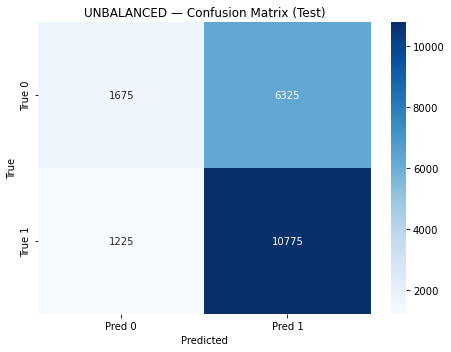


[NOTE] imblearn/SMOTE not available in your environment.
Falling back to class_weight='balanced_subsample' comparison instead.
Error: cannot import name '_MissingValues' from 'sklearn.utils._param_validation' (/apps/python/3.10/lib/python3.10/site-packages/sklearn/utils/_param_validation.py)

=== Training BALANCED model (class_weight='balanced_subsample') ===
Fitting 5 folds for each of 60 candidates, totalling 300 fits


/apps/python/3.10/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



BALANCED best CV F1: 0.7232
BALANCED best params: {'feature_selection__k': 32, 'classifier__n_estimators': 200, 'classifier__min_samples_split': 2, 'classifier__min_samples_leaf': 1, 'classifier__max_features': 0.5, 'classifier__max_depth': None, 'classifier__bootstrap': True}
BALANCED best k: 32
BALANCED selected features (first 60): ['age', 'alcohol_consumption_per_week', 'physical_activity_minutes_per_week', 'diet_score', 'sleep_hours_per_day', 'screen_time_hours_per_day', 'family_history_diabetes', 'hypertension_history', 'cardiovascular_history', 'bmi', 'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate', 'gender_Male', 'gender_Other', 'ethnicity_Black', 'ethnicity_Hispanic', 'ethnicity_Other', 'ethnicity_White', 'education_level_Highschool', 'education_level_No formal', 'education_level_Postgraduate', 'income_level_Low', 'income_level_Lower-Middle', 'income_level_Middle', 'income_level_Upper-Middle', 'employment_status_Retired', 'employment_status_Student', 'employ

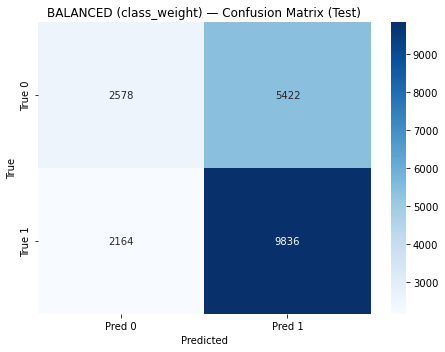


=== TEST SET COMPARISON (same split) ===
     Model  Accuracy       F1  Precision   Recall  ROC_AUC   PR_AUC
Unbalanced    0.6225 0.740550   0.630117 0.897917 0.654964 0.738775
  Balanced    0.6207 0.721696   0.644645 0.819667 0.639703 0.722745

=== Classification Report (Unbalanced) ===
              precision    recall  f1-score   support

           0       0.58      0.21      0.31      8000
           1       0.63      0.90      0.74     12000

    accuracy                           0.62     20000
   macro avg       0.60      0.55      0.52     20000
weighted avg       0.61      0.62      0.57     20000


=== Classification Report (Balanced) ===
              precision    recall  f1-score   support

           0       0.54      0.32      0.40      8000
           1       0.64      0.82      0.72     12000

    accuracy                           0.62     20000
   macro avg       0.59      0.57      0.56     20000
weighted avg       0.60      0.62      0.59     20000



In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, average_precision_score
)

RANDOM_STATE = 42
N_FOLDS = 5
N_ITER = 60  # 30 faster, 80-120 stronger search

# ----------------------------
# Helper utilities
# ----------------------------
def make_numeric_X(df):
    X = pd.get_dummies(df, drop_first=False)
    return X.apply(pd.to_numeric, errors="coerce").fillna(0)

def safe_k_list(n_features, candidates=(6, 8, 10, 20, 30, 50, 100), include_all=True):
    ks = sorted({k for k in candidates if k <= n_features})
    if len(ks) == 0:
        ks = [n_features]
    if n_features not in ks:
        ks.append(n_features)
    if include_all:
        ks.append("all")
    return ks

def eval_binary(y_true, y_pred, y_proba):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true, y_proba),
        "PR_AUC": average_precision_score(y_true, y_proba),
    }

def plot_cm_heatmap(cm, title):
    plt.figure(figsize=(6.5, 5))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=["Pred 0", "Pred 1"],
        yticklabels=["True 0", "True 1"]
    )
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

def selected_feature_names(best_pipeline, X_columns):
    selector = best_pipeline.named_steps["feature_selection"]
    k = selector.k
    if k == "all":
        return "all", list(X_columns)
    idx = selector.get_support(indices=True)
    return k, X_columns[idx].tolist()


# ----------------------------
# 1) Load diagnosed_diabetes dataset
# ----------------------------
df = pd.read_csv("diagnosed_diabetes for classification.csv")
y = df["diagnosed_diabetes"].astype(int)
X = make_numeric_X(df.drop(columns=["diagnosed_diabetes"]))

print("Raw shape:", df.shape)
print("Encoded X shape:", X.shape)
print("Class counts:\n", y.value_counts())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
k_list = safe_k_list(X_train.shape[1])
print("\nSafe k_list:", k_list)


# ----------------------------
# 2) Shared search space (same for both)
# ----------------------------
param_distributions = {
    "feature_selection__k": k_list,
    "classifier__n_estimators": [200, 300, 500, 800],
    "classifier__max_depth": [None, 8, 12, 16, 20],
    "classifier__min_samples_leaf": [1, 2, 5, 10, 20],
    "classifier__min_samples_split": [2, 5, 10, 20],
    "classifier__max_features": ["sqrt", "log2", 0.3, 0.5, 0.8],
    "classifier__bootstrap": [True, False],
}

# ----------------------------
# 3) A) UNBALANCED pipeline/search (no weights, no resampling)
# ----------------------------
pipe_unbalanced = Pipeline([
    ("feature_selection", SelectKBest(score_func=f_classif)),
    ("classifier", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1, class_weight=None))
])

search_unbalanced = RandomizedSearchCV(
    estimator=pipe_unbalanced,
    param_distributions=param_distributions,
    n_iter=N_ITER,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1
)

print("\n=== Training UNBALANCED model (no resampling, no class_weight) ===")
search_unbalanced.fit(X_train, y_train)

best_unbalanced = search_unbalanced.best_estimator_
k_unb, feats_unb = selected_feature_names(best_unbalanced, X_train.columns)

print("\nUNBALANCED best CV F1:", f"{search_unbalanced.best_score_:.4f}")
print("UNBALANCED best params:", search_unbalanced.best_params_)
print("UNBALANCED best k:", k_unb)
print("UNBALANCED selected features (first 60):", feats_unb[:60])

y_pred_unb = best_unbalanced.predict(X_test)
y_proba_unb = best_unbalanced.predict_proba(X_test)[:, 1]
metrics_unb = eval_binary(y_test, y_pred_unb, y_proba_unb)

cm_unb = confusion_matrix(y_test, y_pred_unb, labels=[0, 1])
plot_cm_heatmap(cm_unb, "UNBALANCED — Confusion Matrix (Test)")


# ----------------------------
# 4) B) BALANCED pipeline/search (SMOTE inside CV folds — leakage-safe)
# ----------------------------
try:
    from imblearn.pipeline import Pipeline as ImbPipeline
    from imblearn.over_sampling import SMOTE

    pipe_balanced = ImbPipeline([
        ("feature_selection", SelectKBest(score_func=f_classif)),
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("classifier", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1, class_weight=None))
    ])

    param_distributions_bal = dict(param_distributions)  # same RF + k tuning
    # (Optional) also tune SMOTE neighbors a bit:
    param_distributions_bal["smote__k_neighbors"] = [3, 5, 7]

    search_balanced = RandomizedSearchCV(
        estimator=pipe_balanced,
        param_distributions=param_distributions_bal,
        n_iter=N_ITER,
        scoring="f1",
        cv=cv,
        n_jobs=-1,
        random_state=RANDOM_STATE,
        verbose=1
    )

    print("\n=== Training BALANCED model (SMOTE inside CV folds) ===")
    search_balanced.fit(X_train, y_train)

    best_balanced = search_balanced.best_estimator_
    k_bal, feats_bal = selected_feature_names(best_balanced, X_train.columns)

    print("\nBALANCED best CV F1:", f"{search_balanced.best_score_:.4f}")
    print("BALANCED best params:", search_balanced.best_params_)
    print("BALANCED best k:", k_bal)
    print("BALANCED selected features (first 60):", feats_bal[:60])

    y_pred_bal = best_balanced.predict(X_test)
    y_proba_bal = best_balanced.predict_proba(X_test)[:, 1]
    metrics_bal = eval_binary(y_test, y_pred_bal, y_proba_bal)

    cm_bal = confusion_matrix(y_test, y_pred_bal, labels=[0, 1])
    plot_cm_heatmap(cm_bal, "BALANCED (SMOTE) — Confusion Matrix (Test)")

except Exception as e:
    print("\n[NOTE] imblearn/SMOTE not available in your environment.")
    print("Falling back to class_weight='balanced_subsample' comparison instead.")
    print("Error:", e)

    pipe_balanced = Pipeline([
        ("feature_selection", SelectKBest(score_func=f_classif)),
        ("classifier", RandomForestClassifier(
            random_state=RANDOM_STATE, n_jobs=1, class_weight="balanced_subsample"
        ))
    ])

    search_balanced = RandomizedSearchCV(
        estimator=pipe_balanced,
        param_distributions=param_distributions,
        n_iter=N_ITER,
        scoring="f1",
        cv=cv,
        n_jobs=-1,
        random_state=RANDOM_STATE,
        verbose=1
    )

    print("\n=== Training BALANCED model (class_weight='balanced_subsample') ===")
    search_balanced.fit(X_train, y_train)

    best_balanced = search_balanced.best_estimator_
    k_bal, feats_bal = selected_feature_names(best_balanced, X_train.columns)

    print("\nBALANCED best CV F1:", f"{search_balanced.best_score_:.4f}")
    print("BALANCED best params:", search_balanced.best_params_)
    print("BALANCED best k:", k_bal)
    print("BALANCED selected features (first 60):", feats_bal[:60])

    y_pred_bal = best_balanced.predict(X_test)
    y_proba_bal = best_balanced.predict_proba(X_test)[:, 1]
    metrics_bal = eval_binary(y_test, y_pred_bal, y_proba_bal)

    cm_bal = confusion_matrix(y_test, y_pred_bal, labels=[0, 1])
    plot_cm_heatmap(cm_bal, "BALANCED (class_weight) — Confusion Matrix (Test)")


# ----------------------------
# 5) Summary comparison table
# ----------------------------
summary = pd.DataFrame([
    {"Model": "Unbalanced", **metrics_unb},
    {"Model": "Balanced",   **metrics_bal},
])

print("\n=== TEST SET COMPARISON (same split) ===")
print(summary.to_string(index=False))

print("\n=== Classification Report (Unbalanced) ===")
print(classification_report(y_test, y_pred_unb, zero_division=0))

print("\n=== Classification Report (Balanced) ===")
print(classification_report(y_test, y_pred_bal, zero_division=0))


Raw shape: (100000, 35)
Encoded X shape (Model B): (100000, 34)
Class counts:
 diagnosed_diabetes
1    59998
0    40002
Name: count, dtype: int64

Training RandomizedSearchCV (Model B: WITH glucose)...
Fitting 5 folds for each of 60 candidates, totalling 300 fits


/apps/python/3.10/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



BEST CV F1: 0.8679
BEST PARAMS:
 {'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 10, 'max_features': 'log2', 'max_depth': 20, 'class_weight': None, 'bootstrap': False}

TEST SET METRICS (Model B: WITH glucose)
Accuracy: 0.8431
F1:       0.8643
Precision:0.8985
Recall:   0.8326
ROC-AUC:  0.9132
PR-AUC:   0.9502


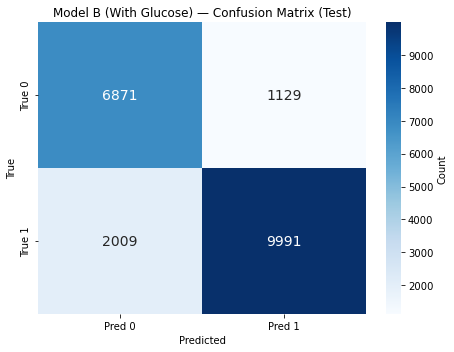


Classification report:

              precision    recall  f1-score   support

 No Diabetes       0.77      0.86      0.81      8000
    Diabetes       0.90      0.83      0.86     12000

    accuracy                           0.84     20000
   macro avg       0.84      0.85      0.84     20000
weighted avg       0.85      0.84      0.84     20000



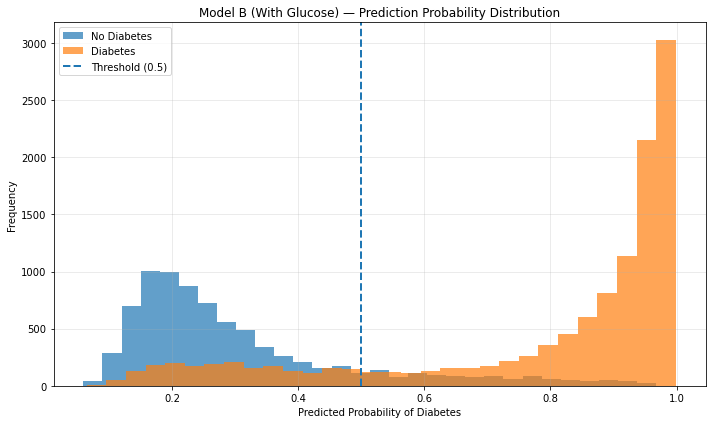


Top 20 feature importances:
glucose_postprandial                  0.574141
glucose_fasting                       0.234824
family_history_diabetes               0.023090
age                                   0.020384
physical_activity_minutes_per_week    0.018868
bmi                                   0.016406
systolic_bp                           0.013877
screen_time_hours_per_day             0.013204
diet_score                            0.012985
sleep_hours_per_day                   0.011847
heart_rate                            0.011023
diastolic_bp                          0.010948
waist_to_hip_ratio                    0.009792
alcohol_consumption_per_week          0.005000
gender_Male                           0.002341
education_level_Highschool            0.002246
ethnicity_White                       0.002169
smoking_status_Never                  0.002089
income_level_Middle                   0.001815
income_level_Lower-Middle             0.001443


In [20]:
# Model B ONLY (WITH glucose) + RandomizedSearchCV (n_iter=60) + 5-fold CV
# - Loads your file
# - Encodes features
# - Train/Test split (stratified, random_state=42)
# - RandomizedSearchCV (5-fold) to maximize F1
# - Prints best params + best CV F1
# - Trains best model (refit) on full TRAIN automatically
# - Evaluates on TEST: Accuracy/F1/Precision/Recall/ROC-AUC/PR-AUC
# - Confusion matrix heatmap + probability distribution
# - Top 20 feature importances

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, average_precision_score
)

RANDOM_STATE = 42
N_FOLDS = 5
N_ITER = 60

FILE = "diabetes_classification_noninvasive with two invasive.csv"
TARGET = "diagnosed_diabetes"
GLUCOSE_COLS = ["glucose_fasting", "glucose_postprandial"]

def make_numeric_X(df):
    X = pd.get_dummies(df, drop_first=False)
    return X.apply(pd.to_numeric, errors="coerce").fillna(0)

def plot_cm(cm, title):
    plt.figure(figsize=(6.5, 5))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=["Pred 0", "Pred 1"],
        yticklabels=["True 0", "True 1"],
        cbar_kws={"label": "Count"},
        annot_kws={"size": 14}
    )
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

# -----------------------------
# 1) Load & prepare Model B data (WITH glucose)
# -----------------------------
df = pd.read_csv(FILE)

if TARGET not in df.columns:
    raise ValueError(f"Target '{TARGET}' not found. Columns (sample): {list(df.columns)[:30]}")

missing = [c for c in GLUCOSE_COLS if c not in df.columns]
if missing:
    raise ValueError(f"Missing glucose columns: {missing}")

y = df[TARGET].astype(int)
X_raw = df.drop(columns=[TARGET])  # Model B: keep everything including glucose
X = make_numeric_X(X_raw)

print("Raw shape:", df.shape)
print("Encoded X shape (with invasive features):", X.shape)
print("Class counts:\n", y.value_counts(dropna=False))

# -----------------------------
# 2) Train/Test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

# -----------------------------
# 3) CV + RandomizedSearchCV
# -----------------------------
cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

rf = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_jobs=1  # avoid nested parallelism; search uses n_jobs=-1
)

param_distributions = {
    "n_estimators": [200, 300, 500, 800],
    "max_depth": [None, 8, 12, 16, 20],
    "min_samples_leaf": [1, 2, 5, 10, 20],
    "min_samples_split": [2, 5, 10, 20],
    "max_features": ["sqrt", "log2", 0.3, 0.5, 0.8],
    "bootstrap": [True, False],
    "class_weight": [None, "balanced_subsample"],
}

search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_distributions,
    n_iter=N_ITER,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1,
    refit=True,               # refit best on full training set
    return_train_score=False
)

print("\nTraining RandomizedSearchCV (Model B: WITH glucose)...")
search.fit(X_train, y_train)

best_model = search.best_estimator_

print("\n" + "="*80)
print("BEST CV F1:", f"{search.best_score_:.4f}")
print("BEST PARAMS:\n", search.best_params_)
print("="*80)

# -----------------------------
# 4) Test evaluation
# -----------------------------
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, zero_division=0)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
roc = roc_auc_score(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)

print("\n" + "="*80)
print("TEST SET METRICS (Model B: WITH glucose)")
print("="*80)
print(f"Accuracy: {acc:.4f}")
print(f"F1:       {f1:.4f}")
print(f"Precision:{prec:.4f}")
print(f"Recall:   {rec:.4f}")
print(f"ROC-AUC:  {roc:.4f}")
print(f"PR-AUC:   {pr_auc:.4f}")

# -----------------------------
# 5) Confusion matrix heatmap
# -----------------------------
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
plot_cm(cm, "Model B (With Glucose) — Confusion Matrix (Test)")

print("\nClassification report:\n")
print(classification_report(y_test, y_pred, target_names=["No Diabetes", "Diabetes"], zero_division=0))

# -----------------------------
# 6) Probability distribution
# -----------------------------
plt.figure(figsize=(10, 6))
plt.hist(y_proba[y_test == 0], bins=30, alpha=0.7, label="No Diabetes")
plt.hist(y_proba[y_test == 1], bins=30, alpha=0.7, label="Diabetes")
plt.axvline(x=0.5, linestyle="--", linewidth=2, label="Threshold (0.5)")
plt.xlabel("Predicted Probability of Diabetes")
plt.ylabel("Frequency")
plt.title("Model B (With Glucose) — Prediction Probability Distribution")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# -----------------------------
# 7) Feature importances (top 20)
# -----------------------------
importances = pd.Series(best_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("\nTop 20 feature importances:")
print(importances.head(20).to_string())



FOLD-BY-FOLD CV RESULTS (TRAIN SET)
 Fold  Accuracy  Precision   Recall       F1  ROC-AUC
    1  0.849938   0.904848 0.838021 0.870153 0.917026
    2  0.844437   0.897662 0.836042 0.865757 0.915938
    3  0.848000   0.899643 0.840417 0.869022 0.914885
    4  0.846688   0.902546 0.834566 0.867226 0.913170
    5  0.846375   0.900325 0.836545 0.867264 0.914614

CV SUMMARY (MEAN ± STD)
   Metric     Mean      Std      Min      Max
 Accuracy 0.847087 0.002040 0.844437 0.849938
Precision 0.901005 0.002767 0.897662 0.904848
   Recall 0.837118 0.002219 0.834566 0.840417
       F1 0.867884 0.001716 0.865757 0.870153
  ROC-AUC 0.915126 0.001451 0.913170 0.917026


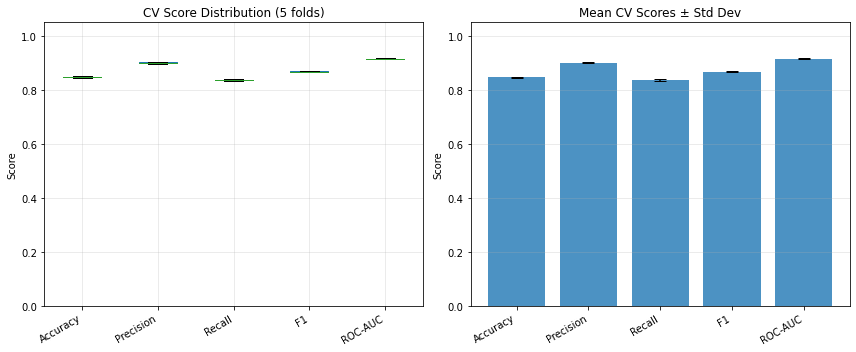

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score

RANDOM_STATE = 42
N_FOLDS = 5

# best_model = search.best_estimator_   # <- from your RandomizedSearchCV
# X_train, y_train = ...               # <- your training data

cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "accuracy": "accuracy",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0),
    "roc_auc": "roc_auc",  # needs predict_proba/decision_function (RF has predict_proba)
}

cv_results = cross_validate(
    best_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)

# ----------------------------
# Fold-by-fold results table
# ----------------------------
fold_results = pd.DataFrame({
    "Fold": np.arange(1, N_FOLDS + 1),
    "Accuracy": cv_results["test_accuracy"],
    "Precision": cv_results["test_precision"],
    "Recall": cv_results["test_recall"],
    "F1": cv_results["test_f1"],
    "ROC-AUC": cv_results["test_roc_auc"],
})

print("\n" + "="*70)
print("FOLD-BY-FOLD CV RESULTS (TRAIN SET)")
print("="*70)
print(fold_results.to_string(index=False))

# ----------------------------
# Summary (mean ± std)
# ----------------------------
metrics = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
means = fold_results[metrics].mean()
stds  = fold_results[metrics].std()

summary = pd.DataFrame({
    "Metric": metrics,
    "Mean": [means[m] for m in metrics],
    "Std":  [stds[m] for m in metrics],
    "Min":  [fold_results[m].min() for m in metrics],
    "Max":  [fold_results[m].max() for m in metrics],
})

print("\n" + "="*70)
print("CV SUMMARY (MEAN ± STD)")
print("="*70)
print(summary.to_string(index=False))

# ----------------------------
# Plots: boxplot + mean±std
# ----------------------------
plt.figure(figsize=(12, 5))

# (1) distribution across folds
plt.subplot(1, 2, 1)
fold_results[metrics].boxplot()
plt.title("CV Score Distribution (5 folds)")
plt.ylabel("Score")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)

# (2) mean ± std
plt.subplot(1, 2, 2)
x = np.arange(len(metrics))
plt.bar(x, [means[m] for m in metrics], yerr=[stds[m] for m in metrics], capsize=6, alpha=0.8)
plt.xticks(x, metrics, rotation=30, ha="right")
plt.ylabel("Score")
plt.title("Mean CV Scores ± Std Dev")
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()
